![Genestack ODM](gs_odm_header.png)
# Single-Cell RNA-Seq: Data Transformation and Upload to ODM

**Contact:** support@genestack.com  

© 2026 Genestack. All rights reserved.

---

This notebook demonstrates how to use the **Genestack ODM API** to  transform, upload and link single-cell RNA-seq data stored in an ODM instance. It explains how to configure the API connection, post the configuration file, inspect the file in 'dry_run' mode and how to run the transformation.
The notebook is organized into four main sections:
* **Prerequisites** – loads the required Python libraries and helper functions. 
* **ODM API Configuration** – an interactive setup for establishing a secure connection to your ODM instance using an API token.
* **Data Import** – imports a demo scRNA-seq dataset (study, sample/library metadata, and H5AD file) into ODM using the `odm-import-data` CLI tool.
* **Working with Data** – Usage of ODM API Processors Controllers endpoints for data transformation.

## 1. Prerequisites

Before running the notebook, make sure your environment is ready. You will need Python 3.10+ and `pip`. Install all dependencies with:
```
pip install pandas ipython ipywidgets python-dotenv odm-sdk anndata scipy scanpy matplotlib
```


### 1.1 Imports

In [ ]:
# standard library (come with Python)
import os
import re
import json
from getpass import getpass
import subprocess

# third-party (need installation)

import odm_api
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.sparse import coo_matrix
from IPython.display import display, HTML
from dotenv import load_dotenv

### 1.2 Functions

This section defines utility functions used across the notebook to streamline interaction with the ODM API and to support visualization of retrieved data. Collecting them here keeps the workflow sections concise and focused on analysis rather than implementation details.

In [ ]:
def set_api_credentials(odm_url, api_prefix='/api/v1'):
    """
    Set ODM API credentials interactively, using getpass or fallback to widget-based UI.

    Attempts to use `getpass` to prompt for an API token (works in terminal environments).
    If that fails (e.g., in JupyterLab or web-based notebooks), falls back to a widget-based input form.

    Parameters
    ----------
    odm_url : str
        The ODM server URL
    api_prefix : str, optional
        The API endpoint prefix (default is '/api/v1').

    Sets global variables
    ------------
        odm_base_url : str
            The base ODM API URL with prefix.
        token : str
            The provided API authentication token.
    """
    # ensure API prefix is provided with the URL
    if not re.search(r'/api.+', odm_url):
        base_url = odm_url + api_prefix

    try:
        # enter token via getpass (works in terminal-based environments)
        global odm_base_url, token

        load_dotenv()
        token = os.getenv("ODM_API_TOKEN")
        
        if not token:
            token = getpass("Auth Token: ")
        odm_base_url = base_url

    except (EOFError, OSError):
        # fallback to widget-based input (works in web environments)
        set_api_credentials_ui(base_url)


def set_api_credentials_ui(base_url):
    """
    Displays widgets for ODM API server and token selection.

    Args:
        base_url (str, optional): Default server URL for ODM with API prefix (e.g. /api/v1).
        If not provided, uses 'ODM_BASE_URL' env variable or default.
    """
    odm_base_url_widget = widgets.Text(
        value=base_url if base_url is not None else os.getenv('ODM_BASE_URL', ''),
        description='Base URL:',
        layout=widgets.Layout(width='600px')
    )
    token_widget = widgets.Password(
        value=os.getenv('ODM_API_TOKEN', ''),
        description='Auth Token:',
        layout=widgets.Layout(width='400px')
    )
    set_button = widgets.Button(description='Set Credentials', button_style='primary')
    status_html = widgets.HTML()

    def _set_credentials(_):
        global odm_base_url, token
        odm_base_url = odm_base_url_widget.value.strip()
        token = token_widget.value.strip()
        masked = ('***' if not token else (token[:4] + '…' + token[-4:] if len(token) >= 8 else '***'))
        status_html.value = f"<span style='color: green;'>Credentials set. Token: {masked}</span>"

    set_button.on_click(_set_credentials)
    display(widgets.VBox([odm_base_url_widget, token_widget, set_button, status_html]))


def display_log_records(logs):
    """
    Display structured log records as a left-aligned, scrollable HTML table.

    Parses log output for JSON records, extracts relevant fields, and renders them
    in a pandas DataFrame as an HTML table for easy viewing in Jupyter notebooks.

    Args:
        logs (bytes or str): Raw log output from transformation jobs.
    """
    logs_str = logs.decode('utf-8') if isinstance(logs, bytes) else logs

    # find all JSON log records (those starting with '{"record":')
    json_records = re.findall(r'{"record":.*?}\n', logs_str)
    records = []
    for rec in json_records:
        try:
            record = json.loads(rec)['record']
            records.append(record)
        except Exception as e:
            pass
    if records:
        df_logs = pd.DataFrame([{
            'Time': r.get('time', {}).get('repr', ''),
            'Level': r.get('level', {}).get('name', ''),
            'Message': r.get('message', ''),
        } for r in records])
        html_table = df_logs.to_html(index=False)

        # add CSS for left alignment
        html_table = html_table.replace('<table', '<table style="text-align:left"')
        html_table = html_table.replace('<td>', '<td style="text-align:left">')
        html_table = html_table.replace('<th>', '<th style="text-align:left">')
        html_table = f'''
            <div style="height:400px; overflow:auto; border:1px solid #ccc;">
            {html_table}
            </div>
            '''
        display(HTML(html_table))
    else:
        print('No log records found.')


def flatten_value(val):
    """Convert lists and dicts to readable strings for table display."""
    if isinstance(val, list):
        return ', '.join(str(v) for v in val)
    elif isinstance(val, dict):
        return json.dumps(val, indent=2)
    else:
        return val
    

def display_expression_metadata(obj):
    """
    Display any object (with .to_dict() or dict-like) as a readable, scrollable table.
    Handles lists and dicts for each attribute.
    """

    if hasattr(obj, 'to_dict'):
        data_dict = obj.to_dict()
    else:
        data_dict = dict(obj)

    rows = []
    for key, value in data_dict.items():
        rows.append({
            'Attribute': key,
            'Value': flatten_value(value)
        })

    df = pd.DataFrame(rows)
    html_table = df.to_html(index=False, escape=False)

    # add CSS for left alignment
    html_table = html_table.replace('<table', '<table style="text-align:left"')
    html_table = html_table.replace('<td>', '<td style="text-align:left">')
    html_table = html_table.replace('<th>', '<th style="text-align:left">')
    scrollable_html = f'''
    <div style="max-height:400px; overflow:auto; border:1px solid #ccc;">
    {html_table}
    </div>
    '''
    display(HTML(scrollable_html))


def extract_accessions_from_logs(logs):
    """
    Extract group accessions from transformation job logs.

    Parses structured JSON log records and returns the accessions for
    the cell, library, and expression groups produced during the job.

    Parameters
    ----------
    logs : bytes or str
        Raw log output from jobs_api.post_api_v1_transformations_jobs_by_id_logs().

    Returns
    -------
    dict
        Keys: 'cell_group_accession', 'library_group_accession', 'expression_group_accession'.
        Values are accession strings (e.g. 'GSF000136') or None if not found.
    """
    logs_str = logs.decode('utf-8') if isinstance(logs, bytes) else logs
    json_records = re.findall(r'{"record":.*?}\n', logs_str)

    patterns = {
        'sample_group_accession': r'[Ss]ample group accession[^:]*:\s*(GSF\w+)',
        'library_group_accession': r'[Ll]ibrary group accession[^:]*:\s*(GSF\w+)',
        'preparation_group_accession': r'[Pp]reparation group accession[^:]*:\s*(GSF\w+)',
        'cell_group_accession': r'[Cc]ell group accession[^:]*:\s*(GSF\w+)',
        'expression_group_accession': r'[Ee]xpression group accession[^:]*:\s*(GSF\w+)',
        'study_group_accession': r'[Ss]tudy accession[^:]*:\s*(GSF\w+)',
    }

    accessions = {key: None for key in patterns}
    for rec in json_records:
        try:
            msg = json.loads(rec)['record'].get('message', '')
            for key, pattern in patterns.items():
                if accessions[key] is None:
                    m = re.search(pattern, msg)
                    if m:
                        accessions[key] = m.group(1)
        except Exception:
            pass

    return accessions


def clean_metadata(expression):
    """
    Transforms expression metadata from dictionaries to a clean DataFrame

    Parameters:
        expression : DataFrame
            Data frame containing gene expression.
    """
    # transforms extracted metadata from gene expression query
    df = expression.copy()
           
    # extract keys from itemOrigin
    for key in ['runSourceId', 'runId', 'groupId']:
        df[key] = df['itemOrigin'].apply(lambda x: x.get(key))
    
    # metadata
    df['Data Class'] = df['metadata'].apply(lambda x: x.get('Data Class'))

    # gene ids
    df['Features (string)'] = df['feature'].apply(lambda x: ' ,'.join(x.keys()))
    for key in ['feature_id', 'geneId']:
        df[key] = df['feature'].apply(lambda x: x.get(key))
    
    # expression
    df['value'] = df['value'].apply(lambda x: x.get('value'))

    columns_keep = ['runSourceId', 'runId', 'groupId', 'Data Class', 'Features (string)',
                    'feature_id', 'geneId', 'value']
    new_df = df[columns_keep]
    return new_df


def create_full_matrix(cells, expression):
    """
    Creates sparse matrix containing cell counts and gene expression values

    Parameters:
        cells: DataFrame
            Data frame containing cell counts and metadata.
        expression : DataFrame
            Data frame containing gene expression and metadata.
    """
    
    # filter expression data to only include cells in provided barcodes
    valid_cells = cells.index
    ex_df_filt = expression[expression['runSourceId'].isin(valid_cells)].copy()

    # get unique genes and cells
    genes_unique = ex_df_filt['feature_id'].unique()
    cells_unique = cells.index

    # create mapping gene / cell - matrix index
    gene_to_idx = {gene: i for i, gene in enumerate(genes_unique)}
    cell_to_idx = {cell: i for i, cell in enumerate(cells_unique)}

    # map expression data to matrix indices. Rows = genes, cols = cells
    row_idx = ex_df_filt['feature_id'].map(gene_to_idx).values
    col_idx = ex_df_filt['runSourceId'].map(cell_to_idx).values 
    data = ex_df_filt['value'].values

    # build sparse matrix (genes x cells)
    counts_matrix = coo_matrix(
    (data, (row_idx, col_idx)),
    shape=(len(genes_unique), len(cells_unique))
    )

    counts_matrix = counts_matrix.tocsr()
    return counts_matrix

## 2. ODM API configuration

**Configuring Access to Your ODM Instance**

Before querying data, establish a connection to your ODM deployment and authenticate using an API token.  
The ODM API uses token-based authentication, allowing secure programmatic access while preserving user-level permissions.

In this section:
* **Specify the ODM instance URL** – defines the environment you are connecting to.  
* **Provide the API token** – identifies and authorizes your user session.  
* **Initialize the ODM API client** – creates the communication layer for all subsequent requests.


In [ ]:
# input ODM server address
server = '<HOST>'  # placeholder for actual ODM instance address

# input API token
set_api_credentials(server)

In [4]:
# credentials sanity check
if len(token)==0:
    print(
        "Failed to paste API token from clipboard!",
        "Set the token manually (e.g. via `token = 'your_token'`)."
    )
else:
    print("Token successfully set!")

Token successfully set!


In [5]:
# initialize API client
configuration = odm_api.Configuration(
    host=server,
    api_key={'Genestack-API-Token': token}
)
api_client = odm_api.ApiClient(configuration)

In [ ]:
# read odm-api documentation
print(f"{server}/user-docs/tools/odm-api/python/generated/")

## 3. Data import

This section imports a publicly available scRNA-seq dataset into ODM as a starting point for the transformation demo. The dataset is a fibrotic liver single-nucleus RNA-seq study (Watson et al., 2023, GEO accession GSE210077).

The `odm-import-data` CLI tool uploads the following assets to ODM:
- **Study metadata** — the top-level study record.
- **Sample and library metadata** — biological and sequencing-level metadata for each specimen.
- **The H5AD file** — attached to the study as a raw data file. The accession returned for this attachment is required when submitting a transformation job.

In [ ]:
import_data = subprocess.run([
    "odm-import-data",
    "--server", server,
    "--token", token,
    "--study", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/study.tsv",
    "--samples", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/samples.tsv",
    "--libraries", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/libraries.tsv",
    "-fl", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/GSE210077_adata_healthy_diseased_nucseq_sparse.h5ad",
    "-flm", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/data.tsv",
    "-dc", "Single-cell transcriptomics",
    "--allow-duplicates"
], capture_output=True, text=True)

In [8]:
# retrieve file accession from import logs
match = re.search(r"file (\w+) was attached successfully", import_data.stdout)
attachment_accession = match.group(1)

## 4. Working with Processors Controller API endpoints

This section covers three key aspects of working with the Processors Controller API:

1. **Transformation configuration**  
   Learn how to define, create, and manage transformation configurations. These configurations specify how data should be processed, including file type, metadata mapping, and processing parameters. You will see how to list available configurations, retrieve details for a specific configuration, and create or update configurations as needed.

2. **Transformation images**  
   Explore the available transformation images, which are containerized processing environments that execute the transformation logic. This part demonstrates how to list and inspect transformation images, including their supported input/output formats and versioning, to ensure compatibility with your data and analysis requirements.

3. **Transformation jobs**  
   Understand how to launch, monitor, and inspect transformation jobs. This includes running jobs in 'dry_run' mode for validation, checking job status, retrieving logs, and accessing the results of completed transformations.

### 4.1 Transformation Configuration
In this step, `TransformationConfigurationsApi` is initialized.

A transformation configuration is a JSON document stored in ODM that describes how a source HDF5 file should be processed. It specifies:

Configurations are stored independently of any particular job, so the same configuration can be reused across multiple files with an identical structure. This section demonstrates how to list available configurations, inspect an existing one, and create a new one from scratch.

In [9]:
# initialize API class
configurations_api = odm_api.TransformationConfigurationsApi(api_client)

#### 4.1.1 Retrieving available transformation configurations

`list_api_v1_transformations_configurations()` returns all configurations stored in your ODM instance. Each entry includes an `id`, `name`, `description` and the actual `data`. The `id` is the key identifier used in all subsequent API calls to reference, update, or run a job against a specific configuration.

In [ ]:
# retrieve and display the available transformation configurations
configs = configurations_api.list_api_v1_transformations_configurations()
if configs is not None:
    df = pd.DataFrame([{
        'id': getattr(cfg, 'id', ''),
        'name': getattr(cfg, 'name', ''),
        'description': getattr(cfg, 'description', '')
    } for cfg in configs])
    display(HTML(df.to_html(index=False)))
else:
    display(HTML("<div style='color: red;'>No transformation configurations available.</div>"))


#### 4.1.2 Create a basic configuration file

A minimal configuration can include the following fields:

- **`file_type`** — the source format (`"h5ad"` or `"h5"`).
- **`cell_metadata.metadata_keys`** — at minimum `{"obs": "metadata"}` to extract standard cell annotations from the AnnData `obs` layer.
- **`feature_metadata.metadata_keys`** — at minimum `{"var": "metadata"}` to extract gene-level annotations.
- **`cell_expression.data_class`** — the `Data Class` of the created Expression Group (e.g. `"Single-cell transcriptomics"`).

This skeleton is a valid starting point. After running a dry run with this configuration, the logs report the file structure and any issues with column naming or linking, which you can use to decide which additional curation rules to add.

`post_api_v1_transformations_configurations()` stores the new configuration in ODM and returns its assigned `id`, which is required for the job submission steps below.

In [11]:
# example: create a basic configuration file
transformation_configuration_fields = odm_api.TransformationConfigurationFields(
    name="initial_config.json",
    description="Initial transformation config",
    data={
        "file_type": "h5ad",
        "cell_metadata": {
            "metadata_keys": {
                "obs": "metadata"
            }
        },
        "feature_metadata": {
            "metadata_keys": {
                "var": "metadata"
            }
        },
        "cell_expression": {
            "data_class": "Single-cell transcriptomics"
        }
    }
)

`post_api_v1_transformations_configurations()` stores the new configuration in ODM and returns its assigned `id`, which is required for the job submission steps below.

In [12]:
# post configuration and retrieve the created configuration with the returned ID
response = configurations_api.post_api_v1_transformations_configurations(
    transformation_configuration_fields
)
config_id = response.id
print(f"Created configuration ID: {config_id}")

Created configuration ID: 835356550


In [13]:
# retrieve details the created configuration
config = configurations_api.get_api_v1_transformations_configurations_by_id(config_id)
print(json.dumps(config.to_dict(), indent=2))

{
  "data": {
    "cell_expression": {
      "data_class": "Single-cell transcriptomics"
    },
    "cell_metadata": {
      "metadata_keys": {
        "obs": "metadata"
      }
    },
    "feature_metadata": {
      "metadata_keys": {
        "var": "metadata"
      }
    },
    "file_type": "h5ad"
  },
  "description": "Initial transformation config",
  "name": "initial_config.json"
}


### 4.2 Transformation Images

A transformation image is a versioned container that executes the processing logic for a given file type. Each image declares the input formats it accepts and the output entity types it can produce. When submitting a job, you select an image by name and version.

For single-cell HDF5 files, the relevant image is **`hdf5-cells`**. It accepts `h5ad` and `h5` inputs and can produce Sample, Library, Preparation, Cell Group, Expression Group, and Attachment outputs.

You can pin a job to a specific version tag for reproducibility, or use `"latest"` to always run with the most recent release.

In [14]:
# initialize API class
images_api = odm_api.TransformationImagesApi(api_client)

#### 4.2.1 Retrieve available Transformation Images

`list_api_v1_transformations_images()` returns all transformation images available on your ODM instance. The cell below filters for `version == "latest"` entries and prints the name, description, accepted input formats, and producible output types for each image. Use this to confirm that the `hdf5-cells` image is available and to identify its supported input/output formats before submitting a job.

In [15]:
# call the API method to get the list of transformation images
response = images_api.list_api_v1_transformations_images()

# extract and print relevant information for each image
for image in response:
    if getattr(image, 'version', '') == 'latest':
        print(f"Name: {getattr(image, 'name', '')}")
        print(f"Description: {getattr(image, 'description', '')}")
        print(f"Input formats: {getattr(image, 'input_formats', [])}")
        print(f"Output formats: {getattr(image, 'output_formats', [])}")
        print('-' * 40)

Name: hdf5-cells
Description: Import single-cell data and metadata from HDF5 format to ODM
Input formats: ['h5ad', 'h5']
Output formats: [<TransformationOutputFormat.SAMPLES: 'samples'>, <TransformationOutputFormat.LIBRARIES: 'libraries'>, <TransformationOutputFormat.PREPARATIONS: 'preparations'>, <TransformationOutputFormat.CELLS: 'cells'>, <TransformationOutputFormat.EXPRESSIONS: 'expressions'>, <TransformationOutputFormat.ATTACHMENTS: 'attachments'>]
----------------------------------------
Name: metadata-basic
Description: Basic converter from attachment to metadata
Input formats: ['csv']
Output formats: [<TransformationOutputFormat.SAMPLES: 'samples'>]
----------------------------------------


### 4.3 Transformation Jobs

A transformation job combines a configuration, an image reference, and one or more input file accessions into a single processing run. The API responds immediately with a `job_id`, which you then use to poll the status and retrieve logs once the run is complete.

The recommended workflow is:

1. **Submit a `dry_run` job** to validate the configuration without uploading any data to ODM. The pipeline runs all metadata extraction and curation steps and reports the file structure, any column mapping issues, and linking validation results.
2. **Review the logs** and update the configuration if needed. Repeat until the dry run completes with status `DONE` and no undesired warnings.
3. **Submit the full job** (`dry_run=False`) to ingest the data. The pipeline compresses the expression matrix, uploads all objects to ODM (Cell Group, Expression Group, and any SLP updates), and links them to the appropriate entity.

This section walks through all three stages for a real dataset.

In [16]:
# initialize API class
jobs_api = odm_api.TransformationJobsApi(api_client)

#### 4.3.1 Run transformation job in 'dry_run' mode

This section walks through a full dry-run iteration cycle: submitting an initial dry-run job, reviewing the resulting logs, updating the configuration based on the findings, and re-running the dry run until it succeeds.

##### 4.3.1.1 Prepare and run `dry-run` transformation with initial configuration file

The `dry_run` mode allows you to simulate the transformation job without actually uploading or modifying any data in ODM. This is a valuable step for validating your configuration and workflow before committing to a full transformation. By running a job in `dry_run` mode, you can:

- Check for errors or warnings in your configuration file.
- Preview the expected processing steps and outputs.
- Ensure compatibility between your configuration, transformation image, and input data.
- Review logs and job status to confirm that the transformation logic is correct.

This approach helps you catch issues early, saving time and preventing unwanted changes to your data. Once the dry run completes successfully, you can confidently proceed to run the actual transformation job.

In [17]:
transformation_job_create_fields = odm_api.TransformationJobCreateFields(
    configuration_id=int(config_id),
    dry_run=True,
    image_reference=odm_api.TransformationImageReference(
        name="hdf5-cells",
        version="latest"
    ),
    input_accessions=[attachment_accession],
    volume_size=30
)

In [18]:
# call the transformation job
response = jobs_api.post_api_v1_transformations_jobs(transformation_job_create_fields)
job_id = response.id
print(f"Job ID: {job_id}")

Job ID: 603969471


In [19]:
# check job status 
job_status = jobs_api.get_api_v1_transformations_jobs_by_id(job_id)
print(f"Job status: {job_status.status.state.value}")

Job status: FAILED


In [20]:
# retrieve and display logs from job id once transformation job is completed
logs_payload = odm_api.LogsPayload()
logs = jobs_api.post_api_v1_transformations_jobs_by_id_logs(job_id, logs_payload)
display_log_records(logs)

Time,Level,Message
2026-03-31 09:53:10.399465+00:00,INFO,Memory limit set to 9.50 GB.
2026-03-31 09:53:10.399748+00:00,INFO,Transformation image name: hdf5-cells.
2026-03-31 09:53:10.399926+00:00,INFO,Transformation image version: 0.1.1.
2026-03-31 09:53:10.400077+00:00,INFO,Configuration ID: 835356550.
2026-03-31 09:53:10.400290+00:00,INFO,Dry run mode enabled! No changes will be made in ODM.
2026-03-31 09:53:10.400435+00:00,INFO,Starting configuration validation...
2026-03-31 09:53:10.400576+00:00,INFO,Validating top-level configuration keys...
2026-03-31 09:53:10.400719+00:00,INFO,Validating cell_metadata configuration...
2026-03-31 09:53:10.400860+00:00,INFO,Validating feature_metadata configuration...
2026-03-31 09:53:10.401003+00:00,INFO,Validating cell_expression configuration...


##### 4.3.1.2 Modify configuration file

In the logs retrieved in the previous section, we observed that for this particular dataset we need to make the following changes:

* **Biosample metadata operations:**
    - Update Samples metadata:
        - Attributes `Condition`, `self_reported_ethnicity_ontology_term_id` and `tissue_type` need to be exported to Samples metadata.
    - Rename exported attributes to standard terminology.
    - Curate values from linking column:
        - The IDs do not match the linking column in Samples metadata, so they need to be renamed.

* **Cell metadata operations**
    - Extract cell-level embeddings:
        - `obsm` and `obsp` objects need to be included in the metadata_keys for them to be extracted and uploaded together with cell metadata.
    - Drop columns:
        - Some cell metadata attributes are already contained in the samples metadata, so they can be dropped.
    - Rename columns:
        - Columns `batch` and `barcode` are mandatory. There is a need to rename the original columns in the file to these values.
        - Additionally, `cell_type_ontology_term_id` can be renamed to the standard `cell_type` attribute.
    - Curate values:
        - As performed for biosamples, there is a need to rename the values in the linking column.

* **Feature metadata operations**
    - Extract feature-level embeddings:
        - `varm` objects needs to be included in the metadata_keys for it to be extracted and uploaded together with feature metadata.
    - Rename columns:
        - Columns `_index_` references the geneIds. It needs to be renamed to `geneId`to perform Gene ID - Gene Name mapping.

In [ ]:
# update config based on needs
transformation_configuration_fields = odm_api.TransformationConfigurationFields(
    name = "modified_config.json",
    description =  "Modified transformation config",
    data = {
        "file_type": "h5ad",
        "biosample_metadata": {
            "metadata_keys": {
                "obs": "metadata"
            },
            "biosample_column_name": "sample_id",
            "sample": {
                "columns_to_export": [
                    "Condition",
                    "self_reported_ethnicity_ontology_term_id",
                    "tissue_type"
                ],
                "columns_renaming_map": {
                    "Condition": "Condition Group",
                    "self_reported_ethnicity_ontology_term_id": "Donor Ethnicity Term ID",
                    "tissue_type": "Cell Source"
                },
                "columns_to_curate_values": {
                    "Sample Source ID": {
                        "AM031": "Liver-32",
                        "AM042": "Liver-13",
                        "AM048": "Liver-14",
                        "AM061": "Liver-18",
                        "AM062": "Liver-33",
                        "AM072": "Liver-34"
                    }
                }
            }
        },
        "cell_metadata": {
            "metadata_keys": {
                "obs": "metadata",
                "obsm": "embedding",
                "obsp": "pairwise"
            },
            "columns_to_drop": [
                "Sex",
                "Age",
                "batch",
                "organism_ontology_term_id",
                "donor_id",
                "development_stage_ontology_term_id",
                "sex_ontology_term_id",
                "disease_ontology_term_id",
                "tissue_ontology_term_id"
            ],
            "columns_renaming_map": {
                "_index": "barcode",
                "sample_id": "batch",
                "cell_type_ontology_term_id": "cell_type"
            },
            "columns_to_curate_values": {
                "batch": {
                    "AM031": "Liver-32",
                    "AM042": "Liver-13",
                    "AM048": "Liver-14",
                    "AM061": "Liver-18",
                    "AM062": "Liver-33",
                    "AM072": "Liver-34"
                }
            }
        },
        "feature_metadata": {
            "metadata_keys": {
                "var": "metadata",
                "varm": "embedding",
            },
            "columns_renaming_map": {
                "_index": "gene"
            },
        },
        "cell_expression": {
            "data_class": "Single-cell transcriptomics"
        }
    }
)

The modified configuration ID is updated in ODM using `put_api_v1_transformations_configurations_by_id` endpoint, which updates the configuration in place rather than creating a new one, being the same ID valid for all subsequent iterations.

In [22]:
# update configuration in ODM instance
configurations_api.put_api_v1_transformations_configurations_by_id(config_id, transformation_configuration_fields)

##### 4.3.1.3 Re-run `dry-run`transformation with the updated configuration file

With the configuration updated, the dry-run job is re-submitted using the same `configuration_id`.

Once the job completes with status `DONE`, review the logs again. Warnings about unmatched `batch` values, unexpected column types, or missing required columns should all be resolved before proceeding to the full run.

In [23]:
# rerun transformation, dry run mode:
response = jobs_api.post_api_v1_transformations_jobs(transformation_job_create_fields)
job_id = response.id
print(f"Job ID: {job_id}")

Job ID: 407960023


In [24]:
# check job status 
job_status = jobs_api.get_api_v1_transformations_jobs_by_id(job_id)
print(f"Job status: {job_status.status.state.value}")

Job status: DONE


In [25]:
# retrieve and display logs from job id:
logs_payload = odm_api.LogsPayload()
logs = jobs_api.post_api_v1_transformations_jobs_by_id_logs(job_id, logs_payload)
display_log_records(logs)

Time,Level,Message
2026-03-31 09:56:02.721236+00:00,INFO,Memory limit set to 9.50 GB.
2026-03-31 09:56:02.721531+00:00,INFO,Transformation image name: hdf5-cells.
2026-03-31 09:56:02.721675+00:00,INFO,Transformation image version: 0.1.1.
2026-03-31 09:56:02.721802+00:00,INFO,Configuration ID: 835356550.
2026-03-31 09:56:02.722009+00:00,INFO,Dry run mode enabled! No changes will be made in ODM.
2026-03-31 09:56:02.722147+00:00,INFO,Starting configuration validation...
2026-03-31 09:56:02.722267+00:00,INFO,Validating top-level configuration keys...
2026-03-31 09:56:02.722385+00:00,INFO,Validating biosample_metadata configuration...
2026-03-31 09:56:02.722511+00:00,INFO,Validating cell_metadata configuration...
2026-03-31 09:56:02.722630+00:00,INFO,Validating feature_metadata configuration...


#### 4.3.2 Run final transformation job

Once the dry run completes successfully, submit the same job with `dry_run` set to `False`. 

The full run executes all pipeline stages:

1. Validates the configuration and retrieves attachment metadata from ODM.
2. Extracts and curates cell metadata, feature metadata, and biosample-level attributes.
3. Compresses the expression matrix using Brotli and writes it to a temporary volume.
4. Uploads the transformed objects to ODM in order: SLP group updates → Cell Group → Expression Group.
5. Links all created objects into the study's entity hierarchy.
6. Saves the full transformation log as an attachment on the study.

In [26]:
transformation_job_create_fields = odm_api.TransformationJobCreateFields(
    configuration_id=int(config_id),
    dry_run=False,
    image_reference=odm_api.TransformationImageReference(
        name="hdf5-cells",
        version="latest"
    ),
    input_accessions=[attachment_accession],
    volume_size=30
)

In [ ]:
# run transformation
response = jobs_api.post_api_v1_transformations_jobs(transformation_job_create_fields)
job_id = response.id

# retrieve job ID from response
print(f"Job ID: {job_id}")

Job ID: 1445644023


In [28]:
# check job status 
job_status = jobs_api.get_api_v1_transformations_jobs_by_id(job_id)
print(f"Job status: {job_status.status.state.value}")

Job status: DONE


In [29]:
# retrieve and display logs from job id once transformation job is completed:
logs_payload = odm_api.LogsPayload()
logs = jobs_api.post_api_v1_transformations_jobs_by_id_logs(job_id, logs_payload)
display_log_records(logs)

Time,Level,Message
2026-03-31 09:58:55.740269+00:00,INFO,Memory limit set to 9.50 GB.
2026-03-31 09:58:55.740575+00:00,INFO,Transformation image name: hdf5-cells.
2026-03-31 09:58:55.740725+00:00,INFO,Transformation image version: 0.1.1.
2026-03-31 09:58:55.740850+00:00,INFO,Configuration ID: 835356550.
2026-03-31 09:58:55.741068+00:00,INFO,Starting configuration validation...
2026-03-31 09:58:55.741210+00:00,INFO,Validating top-level configuration keys...
2026-03-31 09:58:55.741337+00:00,INFO,Validating biosample_metadata configuration...
2026-03-31 09:58:55.741469+00:00,INFO,Validating cell_metadata configuration...
2026-03-31 09:58:55.741593+00:00,INFO,Validating feature_metadata configuration...
2026-03-31 09:58:55.741715+00:00,INFO,Validating cell_expression configuration...


#### 4.3.3 Inspect results from transformation job

After the transformation completes, the job logs contain the accessions of all objects created or updated. This section uses those accessions to verify the results via the relevant ODM API endpoints:

- **4.3.3.1 Updated biosample attributes** — confirm that Sample group was correctly updated and exported.
- **4.3.3.2 Cell metadata** — inspect the per-cell annotations uploaded as a Cell Group.
- **4.3.3.3 Expression metadata** — review the summary statistics (cell count, feature count, sparsity, etc.) stored with the Expression Group.
- **4.3.3.4 Expression data** — query the expression matrix with cell-level filters using the ODM Omics API.

In [30]:
# extract group accessions from transformation job logs
accessions = extract_accessions_from_logs(logs)
cell_group_accession = accessions['cell_group_accession']
sample_group_accession = accessions['sample_group_accession']
library_group_accession = accessions['library_group_accession']
expression_group_accession = accessions['expression_group_accession']
preparation_group_accession = accessions['preparation_group_accession']
study_group_accession = accessions['study_group_accession']

##### 4.3.3.1 Inspect updated biosample attributes

Because `biosample_metadata` was configured with `columns_to_export` for the `sample` entity, the transformation exported biosample-level attributes (e.g. `Condition Group`, `Donor Ethnicity Term ID`, `Cell Source`) from the cell metadata and merged them into the existing Sample group in ODM. Those attributes were also removed from the cell metadata to avoid duplication.

The cells below retrieve the updated Sample group metadata using `SampleSPoTAsUserApi` and display the first few rows to verify that the exported and renamed attributes are present.

In [ ]:
# initialize API client
sample_api = odm_api.SampleSPoTAsUserApi(api_client)

# retrieve data by group accession
sample_data = sample_api.search_samples_as_user(
    query=sample_group_accession,
    returned_metadata_fields="original_data_included"
)
data = sample_data.data
samples_df = pd.DataFrame(data)
display(HTML(samples_df.head().to_html(index=False)))


genestack:accession,Sample Source ID,Sample Name,Organism,Sex,Disease,Age,Age Unit,Tissue,Cell Type,Cell Line,Compound Treatment / Compound,Compound Treatment / Dose,Compound Treatment / Dose Unit,Data Files / Raw,Data Files / Processed,Import Source URL,GEO Sample ID,Date of Sampling,Donor Fibrosis Stage,Condition Group,Donor Ethnicity Term ID,Donor Sex,Donor Age Unit,Species,Comment,Donor Age Range,Cell Source,Donor Age,Developmental Stage,Organ,groupId
GSF001442,Liver-13,AM042,None,None,Healthy,None,None,liver,None,None,None,None,None,None,None,None,GSM6416567,Oct 31 2024,The age was specified in the range between 51 to 60,Normal,unknown,female,year,Homo sapiens,healthy donor with absence of clear signs of acute or chronic injury,0,tissue,51,human adult stage,liver,GSF001441
GSF001443,Liver-14,AM048,None,None,Healthy,None,None,liver,None,None,None,None,None,None,None,None,GSM6416569,Oct 31 2024,The age was specified in the range between 61 to 70,Normal,unknown,male,year,Homo sapiens,healthy donor with absence of clear signs of acute or chronic injury,0,tissue,61,human adult stage,liver,GSF001441
GSF001444,Liver-18,AM061,None,None,Healthy,None,None,liver,None,None,None,None,None,None,None,None,GSM6416578,Oct 31 2024,The age was specified in the range between 81 to 90,Normal,unknown,female,year,Homo sapiens,healthy donor with absence of clear signs of acute or chronic injury,0,tissue,81,human adult stage,liver,GSF001441
GSF001445,Liver-32,AM031,None,None,liver cirrhosis,None,None,liver,None,None,None,None,None,None,None,None,GSM8493744,Feb 05 2025,"[The age was specified in the range between 51 to 60, The stage of fibrosis was specified as F4]",Disease,unknown,male,year,Homo sapiens,fibrotic donor,0,tissue,51,human adult stage,liver,GSF001441
GSF001446,Liver-33,AM062,None,None,liver fibroma,None,None,liver,None,None,None,None,None,None,None,None,GSM8493745,Feb 05 2025,"[The age was specified in the range between 51 to 60, The stage of fibrosis was specified as F2]",Disease,unknown,female,year,Homo sapiens,fibrotic donor,0,tissue,41,human adult stage,liver,GSF001441


##### 4.3.3.2 Cell metadata

The Cell Group contains the per-cell annotations extracted from the H5AD file, curated according to the configuration.

The cell below retrieves the first rows of the Cell Group using `CellsAsUserApi.get_cells_by_group_as_user()`, identified by the `cell_group_accession` extracted from the transformation logs.

In [ ]:
# initialize API client
cell_api = odm_api.CellsAsUserApi(api_client)

# retrieve data by group accession
cell_data = cell_api.get_cells_by_group_as_user(cell_group_accession)
data = cell_data.data
cells_df = pd.DataFrame(data)
display(HTML(cells_df.head().to_html(index=False)))

cellId,barcode,batch,cellType,nCounts,percentMito,umap,pca,log10genesperumiInjured,seuratClustersInjured,celltypeInjured,cellTypeFinalInjured,log10genesperumiHealthy,seuratClustersHealthy,celltypeHealthy,cellTypeFinalHealthy,logCounts,nGenes,assayOntologyTermId,suspensionType,pcaHarmony,meanConnectivities,meanDistances,mitoCounts,riboCounts,percentRibo
GSF001465-Liver.13_AAACCCAAGTTAGTAG.1-1,Liver.13_AAACCCAAGTTAGTAG.1-1,Liver-13,,10051,0.00000,"[-0.46331504, -4.2235503]","[12.137529, 10.891174, 0.12435753, -0.04747507, 0.69676274, -1.4906868, 0.08580877, 0.20459746, -0.20275217, -4.697879, -0.7076968, -3.4512851, 1.1164323, 0.76157415, 1.067887, -0.97995776, 2.3865936, -0.038163453, -0.4267018, 0.2038568, -0.28443533, -1.2139461, -0.8176204, -0.3590163, -0.20638464]",,,,,0.866669959359415,10,Hepatic_stellate_cells,HSC_1,9.215427,2928,,na,"10.553474,9.898809,-0.040885687,-0.24276683,0.62996423,-1.1808891,0.25137967,0.1368121,0.3095448,-2.5801508,-0.25513768,-3.1873329,0.66923505,0.67019945,0.7666667,-0.6618811,1.3341376,-0.109150626,0.02376286,0.23336272,0.18955815,-0.82932395,-0.5879295,0.13551255,-0.21027641",0.00048978464,0.0009054886964158516,0,15,0.14923888170331312
GSF001465-Liver.13_AAACCCACAATGTGGG.1-1,Liver.13_AAACCCACAATGTGGG.1-1,Liver-13,,5329,0.00000,"[10.219194, 4.1265607]","[-3.386281, -0.09895378, -0.04621607, -0.29931396, 0.5865491, -0.071433425, -0.71152914, 0.82993305, -2.580983, -0.53464556, -1.5554526, -0.4212112, 0.40156704, -1.4147602, -0.6464496, -1.3782663, -0.20468915, 0.75898725, -0.33518443, -0.036190875, 0.43066734, 0.43392974, 0.5888648, -0.20781413, -0.5582827]",,,,,0.898247925746093,0,Hepatocytes,Hep_1,8.580919,2221,,na,"-2.9538522,-0.21806423,-0.23180369,-0.4187424,-0.23022524,-0.44066992,0.22957425,0.3114095,-1.3132601,-0.5378268,-0.8687273,-0.34057027,-0.41601557,-0.85106146,-0.050436877,-0.7458186,-0.1769908,0.3803419,-0.48090598,0.13082139,0.2703654,0.34653482,0.52414215,-0.085541815,-0.18692447",0.00035890169,0.0007847628849323784,0,13,0.24394820791893415
GSF001465-Liver.13_AAACCCACACCTCGTT.1-1,Liver.13_AAACCCACACCTCGTT.1-1,Liver-13,,8119,0.03695,"[10.698837, 10.0404415]","[-3.237879, -0.2842459, 0.040820267, 0.41713125, 2.527977, 0.4704482, -0.6760496, 0.3635924, -1.2898221, -0.62887806, 0.00015130639, -0.12488869, 0.5154322, -1.6777186, -0.57207483, -0.7306467, -0.18149775, 0.5146872, 0.25703782, -0.3460521, -0.98864716, 0.3733704, 0.49249998, -0.27478778, -0.26778132]",,,,,0.890666783522695,12,Hepatocytes,Hep_1,9.001963,3027,,na,"-3.1251893,-0.28575116,0.45323956,0.7210219,1.4092761,0.48360983,1.7175963,-0.36678275,-0.4893254,-0.5937992,-0.11507254,-0.029103996,-0.31389016,-1.1276149,-0.13470866,-0.33079502,0.1342674,0.2205748,0.02598448,-0.0096917385,-0.84620255,0.25201228,0.46555117,0.0575808,-0.062030327",0.00021373578,0.0011001621671241609,3,26,0.3202364823254095
GSF001465-Liver.13_AAACCCACATGACAAA.1-1,Liver.13_AAACCCACATGACAAA.1-1,Liver-13,,1930,0.00000,"[-0.44443342, 1.6000901]","[3.0589175, 0.49618077, -3.0585284, -1.1382377, -4.4574466, 8.165003, -1.5523858, -2.9164038, 0.8543454, -0.6008927, -0.5070977, -0.8298889, 1.4379351, -0.66211635, -0.64119536, -0.5424429, 0.6179339, -0.7145697, -0.20161863, -0.31053472, 0.08975838, -0.7875952, 0.18320867, 0.07898295, 0.24929231]",,,,,0.932007104808123,15,Cholangiocytes,Cholangiocyte,7.565275,1153,,na,"2.622915,0.20523937,-2.9457474,-0.9995415,-3.8118005,6.968292,-1.153877,-2.4826045,0.9582852,-0.3770631,-0.344779,-0.70574844,1.13063,-0.4140951,-0.541899,-0.3367265,0.53932625,-0.39598343,-0.23717938,-0.13744703,0.3600897,-0.58889496,0.075596936,0.17723697,0.16214609",0.00035972366,0.0009198429809042988,0,3,0.15544041450777202
GSF001465-Liver.13_AAACCCAGTTGAGTCT.1-1,Liver.13_AAACCCAGTTGAGTCT.1-1,Liver-13,,6327,0.00000,"[14.2533455, 6.295877]","[-3.260874, 0.0629348, -0.01612958, -0.50689435, 1.463825, 0.33993548, -1.3671178, 0.27602586, -0.86476564, -0.57713753, 0.3778471, 0.0005850047, -0.47138596, -0.2833045, -0.0059300954, -1.2339453, -

##### 4.3.3.3 Expression metadata

The Expression Group holds summary statistics for the uploaded expression matrix together with provenance metadata. The cell below retrieves the full metadata record using `ExpressionSPoTAsUserApi.get_expression_group_as_user()` and displays it as a key-value table.

In [ ]:
# initialize API client
expression_api = odm_api.ExpressionSPoTAsUserApi(api_client)

# retrieve data by group accession
expression_data = expression_api.get_expression_group_as_user(
    id=expression_group_accession,
    returned_metadata_fields="original_data_included")
data = expression_data.metadata
display_expression_metadata(data)

Attribute,Value
Experimental Platform,Illumina NovaSeq 6000
Processing QC,Remove low-UMI nuclei; doublets removed
Values (numeric),None
Source,"Data was obtained from the Human Cell Atlas repository, project FibroticLiverWatsonMERFISH. Data available in https://explore.data.humancellatlas.org/projects/64809a52-f703-4aec-b3a5-eca808a971d0"
Name,None
Pipeline ID,None
Total Number of Cells or Nuclei,27692
Features (string),None
Library Preparation Protocol,10x Genomics Chromium Single Cell 3′
Alignment & Quantification Method,Integration mapping with Cell Ranger v7.0.1


##### 4.3.3.4 Expression data


This section provides an example of how to query and visualise gene expression data from ODM. Wait until indexing has completed after the transformation job before running the cells below.

The expression matrix can be queried at single-cell resolution using `OmicsQueriesAsUserApi`, with cell-level filters applied to restrict results to high-quality cells. The retrieved expression data is assembled into an `AnnData` object and visualised as violin plots grouped by cell type.

In [48]:
# initialize API client
omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

In [ ]:
# define search parameters
genes = ["ALB", "HNF4A", "CYP3A4", "ARG1", "GOT1", "ACTA2"]

# filter by mitochondrial percentage and counts to focus on higher quality cells
cell_query = " AND ".join([
    'percentMito <= 5',
    '(nCounts > 1000 AND nCounts < 15000)'
])

# iterate over genes
ex_list = []
for gene in genes:
    ex_gene = omics_api.omics_search_cells_expression_data_as_user(
        study_query=study_group_accession,
        ex_query="feature=" + gene,
        cell_query=cell_query,
        page_limit=20000
      )
    
    df = pd.DataFrame([item for item in ex_gene.data])
    ex_list.append(df)
    print(f"Found {len(df)} cells with gene {gene}.")

# combine all information into a single metadata table
if all(df.empty for df in ex_list):
    print("No expression data could be retrieved. Wait until indexing has "
          "completed and rerun this cell.")
else:
    ex_df = clean_metadata(pd.concat(ex_list, ignore_index=True))

Found 5254 cells with gene ALB.
Found 9971 cells with gene HNF4A.
Found 8773 cells with gene CYP3A4.
Found 15164 cells with gene ARG1.
Found 9796 cells with gene GOT1.
Found 755 cells with gene ACTA2.


In [ ]:
# set barcode as index to facilitate matrix construction
cells_df = cells_df.set_index("barcode")

In [ ]:
# create AnnData object
counts_matrix = create_full_matrix(cells_df, ex_df)
genes_unique = ex_df['feature_id'].unique()
cells_unique = cells_df.index

adata = ad.AnnData(
    X=counts_matrix.T,
    obs=cells_df.loc[cells_unique].copy(),
    var=pd.DataFrame(index=genes_unique)
)

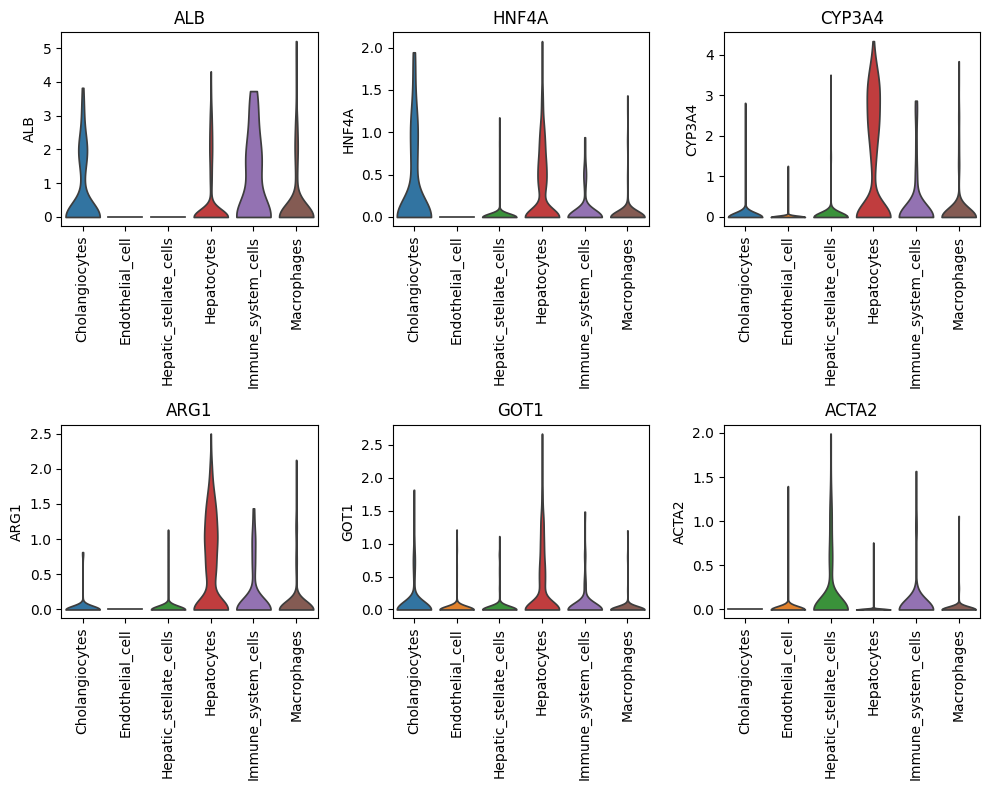

In [ ]:
# plot violin with 2x3 grid layout
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

for idx, gene in enumerate(genes):
    sc.pl.violin(
        adata,
        keys=gene,
        groupby="celltypeHealthy",
        stripplot=False,
        rotation=90,
        multi_panel=False,
        ax=axes[idx],
        size=1,
        show=False
    )
    axes[idx].set_title(gene)

plt.tight_layout()
plt.show()